In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [2]:
def f1_from_nonzero(A_true, A_est):
    A_true_nz = (A_true != 0)
    A_est_nz  = (A_est  != 0)

    TP = np.sum(A_true_nz & A_est_nz)
    FP = np.sum(~A_true_nz & A_est_nz)
    FN = np.sum(A_true_nz & ~A_est_nz)

    precision = TP / (TP + FP + 1e-12)
    recall    = TP / (TP + FN + 1e-12)
    f1        = 2 * precision * recall / (precision + recall + 1e-12)

    return TP, FP, FN, precision, recall, f1

## Overall f1 

#### Legend

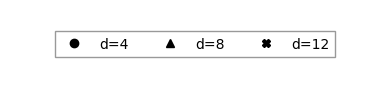

In [ ]:
case_handles = [
    Line2D([0], [0], marker='o', color='black', linestyle='None', label='d=4'),
    Line2D([0], [0], marker='^', color='black', linestyle='None', label='d=8'),
    Line2D([0], [0], marker='X', color='black', linestyle='None', label='d=12'),
]

fig = plt.figure(figsize=(4, 1))

leg = fig.legend(
    handles=case_handles,
    # title="Case",
    loc="center",
    ncol=3,
    frameon=True,              
    fancybox=False             
)

frame = leg.get_frame()
frame.set_edgecolor('gray')   
frame.set_linewidth(1.0)
frame.set_facecolor('white')  

plt.axis('off')
plt.tight_layout()
plt.savefig("legend_case.pdf", bbox_inches='tight')
plt.show()

#### Plots

In [ ]:
def admg_to_adjacency(admg: dict):
    """
    Convert ADMG dict to directed and bidirected adjacency matrices.

    Returns:
        A_dir   : [d, d] numpy array, A_dir[i, j] = 1 if i -> j
        A_bidir : [d, d] numpy array, A_bidir[i, j] = 1 if i <-> j
    """
    nodes = sorted(int(k) for k in admg.keys())
    d = len(nodes)

    A_dir = np.zeros((d, d), dtype=int)
    A_bidir = np.zeros((d, d), dtype=int)

    for v_str, info in admg.items():
        v = int(v_str)
        for u in info.get("parents", []):
            A_dir[u, v] = 1

        for u in info.get("spouses", []):
            A_bidir[u, v] = 1
            A_bidir[v, u] = 1  

    return A_dir, A_bidir

def prf(TP, FP, FN):
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1        = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )
    return precision, recall, f1

In [ ]:
g = "ancestral"
m = "func"
result_dic = {}
folder = {f"d4_{g}_{m}", f"d4_linear_{g}_{m}", f"d4_nonlinear_{g}_{m}", f"d4_fci_{g}_{m}"}  

for f in folder:
    if "nonlinear" in f:
        W1_thres = 0.5
        W2_thres = 0.5
    else:
        W1_thres = 0.3
        W2_thres = 0.2
    TP_tot_W1 = 0
    FP_tot_W1 = 0
    FN_tot_W1 = 0

    TP_tot_W2 = 0
    FP_tot_W2 = 0
    FN_tot_W2 = 0

    run_time_count = 0
    run_time_tot = 0
    tot = 0

    for filename in os.listdir(f):

        file_path = os.path.join(f, filename)
        print("Processing:", file_path)

        with open(file_path, "r") as d:
            data = json.load(d)

        # --- truth ---
        admg = data["admg"]
        W_truth, Sigma_truth = admg_to_adjacency(admg)
        # W_truth = np.array(data["W_truth"])
        # Sigma_truth = np.array(data["Sigma_truth"])  # assumes this key exists

        # W_truth[np.abs(W_truth) < W1_thres] = 0
        # Sigma_truth[np.abs(Sigma_truth) < W2_thres] = 0

        # --- pick run_id == 0 ---
        W_est = None
        Sigma_est = None
        chosen_run = None

        if "nonlinear" in f:
            W_est = np.array(data["directed_adj_final"]) 
            Sigma_est = np.array(data["bidirected_adj_final"])
            run_time = data.get("train_running_time_mean")
            W_est[np.abs(W_est) < W1_thres] = 0
            Sigma_est[np.abs(Sigma_est) < W2_thres] = 0
            
        elif "linear" in f or "fci" in f:
            W_est = np.array(data["A_dir"])
            Sigma_est = np.array(data["A_bidir"])
            run_time = data["run_time_sec"]
       
        else:
            for run in data["random_runs"]:
                if run["run_id"] == 0:
                    chosen_run = run
                    W_est = np.array(run["W_est_random"])
                    Sigma_est = np.array(run["Sigma_est_random"])
                    run_time = run["run_time_sec"]
                    W_est[np.abs(W_est) < W1_thres] = 0
                    Sigma_est[np.abs(Sigma_est) < W2_thres] = 0
                    break

        if W_est is None or Sigma_est is None:
            print(f"  Skipping {filename}: run_id == 0 not found.")
            continue

        # --- F1 for W ---
        TP_W1, FP_W1, FN_W1, precision_W1, recall_W1, f1_W1 = f1_from_nonzero(W_truth, W_est)

        # --- F1 for Sigma (strictly lower-triangular) ---
        TP_W2, FP_W2, FN_W2, precision_W2, recall_W2, f1_W2 = f1_from_nonzero(
            np.tril(Sigma_truth, k=-1),
            np.tril(Sigma_est,   k=-1),
        )

        TP_tot_W1 += TP_W1
        FP_tot_W1 += FP_W1
        FN_tot_W1 += FN_W1

        TP_tot_W2 += TP_W2
        FP_tot_W2 += FP_W2
        FN_tot_W2 += FN_W2

        tot += 1
        if run_time is not None and np.isfinite(run_time):
            run_time_tot += float(run_time)
            run_time_count += 1
        else:
            print(f"  Warning: runtime missing in {filename}")

    precision_W1, recall_W1, f1_W1 = prf(TP_tot_W1, FP_tot_W1, FN_tot_W1)
    precision_W2, recall_W2, f1_W2 = prf(TP_tot_W2, FP_tot_W2, FN_tot_W2)

    run_time_avg = run_time_tot / run_time_count if run_time_count > 0 else 0

    result_dic[f"{f}_precision_W1"]=precision_W1
    result_dic[f"{f}_recall_W1"]=recall_W1
    result_dic[f"{f}_f1_W1"]=f1_W1

    result_dic[f"{f}_precision_W2"]=precision_W2
    result_dic[f"{f}_recall_W2"]=recall_W2
    result_dic[f"{f}_f1_W2"]=f1_W2
    result_dic[f"{f}_run_time"]=run_time_avg
    result_dic[f"{f}_failure_rate"]=1-tot/100

In [39]:
result_dic

{'d4_fci_ancestral_func_precision_W1': np.float64(0.5714285714285714),
 'd4_fci_ancestral_func_recall_W1': np.float64(0.042105263157894736),
 'd4_fci_ancestral_func_f1_W1': np.float64(0.0784313725490196),
 'd4_fci_ancestral_func_precision_W2': np.float64(0.6896551724137931),
 'd4_fci_ancestral_func_recall_W2': np.float64(0.11764705882352941),
 'd4_fci_ancestral_func_f1_W2': np.float64(0.20100502512562812),
 'd4_fci_ancestral_func_run_time': 0.22308697387576104,
 'd4_fci_ancestral_func_failure_rate': 0.0,
 'd4_ancestral_func_precision_W1': np.float64(0.8141025641025641),
 'd4_ancestral_func_recall_W1': np.float64(0.6684210526315789),
 'd4_ancestral_func_f1_W1': np.float64(0.7341040462427746),
 'd4_ancestral_func_precision_W2': np.float64(0.9395973154362416),
 'd4_ancestral_func_recall_W2': np.float64(0.8235294117647058),
 'd4_ancestral_func_f1_W2': np.float64(0.877742946708464),
 'd4_ancestral_func_run_time': 2915.79834921211,
 'd4_ancestral_func_failure_rate': 0.0,
 'd4_nonlinear_ances

In [ ]:
folder = {f"d8_{g}_{m}", f"d8_linear_{g}_{m}", f"d8_nonlinear_{g}_{m}", f"d8_fci_{g}_{m}"}   

for f in folder:
    if "nonlinear" in f:
        W1_thres = 0.5
        W2_thres = 0.5
    else:
        W1_thres = 0.3
        W2_thres = 0.2
    TP_tot_W1 = 0
    FP_tot_W1 = 0
    FN_tot_W1 = 0

    TP_tot_W2 = 0
    FP_tot_W2 = 0
    FN_tot_W2 = 0

    run_time_count = 0
    run_time_tot = 0
    tot = 0

    for filename in os.listdir(f):

        file_path = os.path.join(f, filename)
        print("Processing:", file_path)

        with open(file_path, "r") as d:
            data = json.load(d)

        # --- truth ---
        admg = data["admg"]
        W_truth, Sigma_truth = admg_to_adjacency(admg)
        # W_truth = np.array(data["W_truth"])
        # Sigma_truth = np.array(data["Sigma_truth"])  # assumes this key exists

        # W_truth[np.abs(W_truth) < W1_thres] = 0
        # Sigma_truth[np.abs(Sigma_truth) < W2_thres] = 0

        # --- pick run_id == 0 ---
        W_est = None
        Sigma_est = None
        chosen_run = None

        if "nonlinear" in f:
            W_est = np.array(data["directed_adj_final"]) 
            Sigma_est = np.array(data["bidirected_adj_final"])
            run_time = data.get("train_running_time_mean")
            W_est[np.abs(W_est) < W1_thres] = 0
            Sigma_est[np.abs(Sigma_est) < W2_thres] = 0
            
        elif "linear" in f or "fci" in f:
            W_est = np.array(data["A_dir"])
            Sigma_est = np.array(data["A_bidir"])
            run_time = data["run_time_sec"]
       
        else:
            for run in data["random_runs"]:
                if run["run_id"] == 0:
                    chosen_run = run
                    W_est = np.array(run["W_est_random"])
                    Sigma_est = np.array(run["Sigma_est_random"])
                    run_time = run["run_time_sec"]
                    W_est[np.abs(W_est) < W1_thres] = 0
                    Sigma_est[np.abs(Sigma_est) < W2_thres] = 0
                    break

        if W_est is None or Sigma_est is None:
            print(f"  Skipping {filename}: run_id == 0 not found.")
            continue

        # --- F1 for W ---
        TP_W1, FP_W1, FN_W1, precision_W1, recall_W1, f1_W1 = f1_from_nonzero(W_truth, W_est)

        # --- F1 for Sigma (strictly lower-triangular) ---
        TP_W2, FP_W2, FN_W2, precision_W2, recall_W2, f1_W2 = f1_from_nonzero(
            np.tril(Sigma_truth, k=-1),
            np.tril(Sigma_est,   k=-1),
        )

        TP_tot_W1 += TP_W1
        FP_tot_W1 += FP_W1
        FN_tot_W1 += FN_W1

        TP_tot_W2 += TP_W2
        FP_tot_W2 += FP_W2
        FN_tot_W2 += FN_W2

        tot += 1
        if run_time is not None and np.isfinite(run_time):
            run_time_tot += float(run_time)
            run_time_count += 1
        else:
            print(f"  Warning: runtime missing in {filename}")

    precision_W1, recall_W1, f1_W1 = prf(TP_tot_W1, FP_tot_W1, FN_tot_W1)
    precision_W2, recall_W2, f1_W2 = prf(TP_tot_W2, FP_tot_W2, FN_tot_W2)

    run_time_avg = run_time_tot / run_time_count if run_time_count > 0 else 0

    result_dic[f"{f}_precision_W1"]=precision_W1
    result_dic[f"{f}_recall_W1"]=recall_W1
    result_dic[f"{f}_f1_W1"]=f1_W1

    result_dic[f"{f}_precision_W2"]=precision_W2
    result_dic[f"{f}_recall_W2"]=recall_W2
    result_dic[f"{f}_f1_W2"]=f1_W2
    result_dic[f"{f}_run_time"]=run_time_avg
    result_dic[f"{f}_failure_rate"]=1-tot/100

       

In [41]:
result_dic

{'d4_fci_ancestral_func_precision_W1': np.float64(0.5714285714285714),
 'd4_fci_ancestral_func_recall_W1': np.float64(0.042105263157894736),
 'd4_fci_ancestral_func_f1_W1': np.float64(0.0784313725490196),
 'd4_fci_ancestral_func_precision_W2': np.float64(0.6896551724137931),
 'd4_fci_ancestral_func_recall_W2': np.float64(0.11764705882352941),
 'd4_fci_ancestral_func_f1_W2': np.float64(0.20100502512562812),
 'd4_fci_ancestral_func_run_time': 0.22308697387576104,
 'd4_fci_ancestral_func_failure_rate': 0.0,
 'd4_ancestral_func_precision_W1': np.float64(0.8141025641025641),
 'd4_ancestral_func_recall_W1': np.float64(0.6684210526315789),
 'd4_ancestral_func_f1_W1': np.float64(0.7341040462427746),
 'd4_ancestral_func_precision_W2': np.float64(0.9395973154362416),
 'd4_ancestral_func_recall_W2': np.float64(0.8235294117647058),
 'd4_ancestral_func_f1_W2': np.float64(0.877742946708464),
 'd4_ancestral_func_run_time': 2915.79834921211,
 'd4_ancestral_func_failure_rate': 0.0,
 'd4_nonlinear_ances

In [ ]:
folder = {f"d12_{g}_{m}", f"d12_linear_{g}_{m}", f"d12_nonlinear_{g}_{m}", f"d12_fci_{g}_{m}"}  

for f in folder:
    if "nonlinear" in f:
        W1_thres = 0.5
        W2_thres = 0.5
    else:
        W1_thres = 0.3
        W2_thres = 0.2
    TP_tot_W1 = 0
    FP_tot_W1 = 0
    FN_tot_W1 = 0

    TP_tot_W2 = 0
    FP_tot_W2 = 0
    FN_tot_W2 = 0

    run_time_count = 0
    run_time_tot = 0
    tot = 0

    for filename in os.listdir(f):

        file_path = os.path.join(f, filename)
        print("Processing:", file_path)

        with open(file_path, "r") as d:
            data = json.load(d)

        # --- truth ---
        admg = data["admg"]
        W_truth, Sigma_truth = admg_to_adjacency(admg)
        # W_truth = np.array(data["W_truth"])
        # Sigma_truth = np.array(data["Sigma_truth"])  # assumes this key exists

        # W_truth[np.abs(W_truth) < W1_thres] = 0
        # Sigma_truth[np.abs(Sigma_truth) < W2_thres] = 0

        # --- pick run_id == 0 ---
        W_est = None
        Sigma_est = None
        chosen_run = None

        if "nonlinear" in f:
            W_est = np.array(data["directed_adj_final"]) 
            Sigma_est = np.array(data["bidirected_adj_final"])
            run_time = data.get("train_running_time_mean")
            W_est[np.abs(W_est) < W1_thres] = 0
            Sigma_est[np.abs(Sigma_est) < W2_thres] = 0
            
        elif "linear" in f or "fci" in f:
            W_est = np.array(data["A_dir"])
            Sigma_est = np.array(data["A_bidir"])
            run_time = data["run_time_sec"]
       
        else:
            for run in data["random_runs"]:
                if run["run_id"] == 0:
                    chosen_run = run
                    W_est = np.array(run["W_est_random"])
                    Sigma_est = np.array(run["Sigma_est_random"])
                    run_time = run["run_time_sec"]
                    W_est[np.abs(W_est) < W1_thres] = 0
                    Sigma_est[np.abs(Sigma_est) < W2_thres] = 0
                    break

        if W_est is None or Sigma_est is None:
            print(f"  Skipping {filename}: run_id == 0 not found.")
            continue

        # --- F1 for W ---
        TP_W1, FP_W1, FN_W1, precision_W1, recall_W1, f1_W1 = f1_from_nonzero(W_truth, W_est)

        # --- F1 for Sigma (strictly lower-triangular) ---
        TP_W2, FP_W2, FN_W2, precision_W2, recall_W2, f1_W2 = f1_from_nonzero(
            np.tril(Sigma_truth, k=-1),
            np.tril(Sigma_est,   k=-1),
        )

        TP_tot_W1 += TP_W1
        FP_tot_W1 += FP_W1
        FN_tot_W1 += FN_W1

        TP_tot_W2 += TP_W2
        FP_tot_W2 += FP_W2
        FN_tot_W2 += FN_W2

        tot += 1
        if run_time is not None and np.isfinite(run_time):
            run_time_tot += float(run_time)
            run_time_count += 1
        else:
            print(f"  Warning: runtime missing in {filename}")

    precision_W1, recall_W1, f1_W1 = prf(TP_tot_W1, FP_tot_W1, FN_tot_W1)
    precision_W2, recall_W2, f1_W2 = prf(TP_tot_W2, FP_tot_W2, FN_tot_W2)

    run_time_avg = run_time_tot / run_time_count if run_time_count > 0 else 0

    result_dic[f"{f}_precision_W1"]=precision_W1
    result_dic[f"{f}_recall_W1"]=recall_W1
    result_dic[f"{f}_f1_W1"]=f1_W1

    result_dic[f"{f}_precision_W2"]=precision_W2
    result_dic[f"{f}_recall_W2"]=recall_W2
    result_dic[f"{f}_f1_W2"]=f1_W2
    result_dic[f"{f}_run_time"]=run_time_avg
    result_dic[f"{f}_failure_rate"]=1-tot/100

In [ ]:
methods = {}
for k, v in result_dic.items():
    parts = k.split("_")
    if "_f1_" in k:
        method = "_".join(parts[:-2])   
        metric = parts[-1]             
        methods.setdefault(method, {})[metric] = float(v)

    elif k.endswith("_run_time"):
        method = "_".join(parts[:-2])   # remove "run_time"
        methods.setdefault(method, {})["run_time"] = float(v)

    elif k.endswith("_failure_rate"):
        method = "_".join(parts[:-2])   # remove "failure_rate"
        methods.setdefault(method, {})["failure_rate"] = float(v)

methods

{'d4_fci_ancestral_func': {'W1': 0.0784313725490196,
  'W2': 0.20100502512562812,
  'run_time': 0.22308697387576104,
  'failure_rate': 0.0},
 'd4_ancestral_func': {'W1': 0.7341040462427746,
  'W2': 0.877742946708464,
  'run_time': 2915.79834921211,
  'failure_rate': 0.0},
 'd4_nonlinear_ancestral_func': {'W1': 0.2447058823529412,
  'W2': 0.35714285714285715,
  'run_time': 210.2115916122198,
  'failure_rate': 0.0},
 'd4_linear_ancestral_func': {'W1': 0.4699453551912569,
  'W2': 0.49511400651465803,
  'run_time': 32.32525576040149,
  'failure_rate': 0.0},
 'd8_nonlinear_ancestral_func': {'W1': 0.3144329896907217,
  'W2': 0.20833333333333331,
  'run_time': 277.56012111915066,
  'failure_rate': 0.69},
 'd8_fci_ancestral_func': {'W1': 0.16033755274261605,
  'W2': 0.4555160142348755,
  'run_time': 0.2838169679790735,
  'failure_rate': 0.0},
 'd8_ancestral_func': {'W1': 0.6956521739130435,
  'W2': 0.8789808917197452,
  'run_time': 7296.600615571514,
  'failure_rate': 0.0},
 'd8_linear_ancestr

In [44]:
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

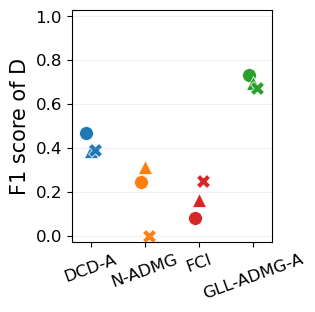

In [ ]:
offset_map = {'d4': -0.08, 'd8': 0.0, 'd12': 0.08}
x_labels = ["DCD-A", "N-ADMG", "FCI", "GLL-ADMG-A"] if g=="ancestral" else ["DCD-BF", "N-ADMG", "FCI", "GLL-ADMG-BF"]
method_pos = {'linear': 0, 'nonlinear': 1, 'fci': 2, 'base': 3}
marker_map = {'d4': 'o', 'd8': '^', 'd12': 'X'}
color_map = {
    'linear': 'tab:blue',
    'nonlinear': 'tab:orange',
    'fci': 'tab:red',
    'base': 'tab:green'
}

plt.figure(figsize=(3.0, 3.0))

for name, vals in methods.items():

    if "_nonlinear" in name:
        method = "nonlinear"
    elif "_linear" in name:
        method = "linear"
    elif "_fci" in name:
        method = "fci"
    else:
        method = "base"

    if "d4" in name:
        dim = "d4"
    elif "d8" in name:
        dim = "d8"
    elif "d12" in name:
        dim = "d12"
    else:
        continue

    x = method_pos[method] + offset_map[dim]
    y = vals["W1"]          

    plt.scatter(x, y, marker=marker_map[dim], color=color_map[method], s=100, edgecolors='white',  

    linewidths=0.5)

dim_order = ['d4', 'd8', 'd12']

for dim, marker in marker_map.items():
    label = f"d={dim[1:]}"
    plt.scatter([], [], marker=marker, color='black', label=label)

plt.xticks([0, 1, 2, 3], x_labels, rotation=20)
plt.ylim(-0.03, 1.03)
plt.xlim(-0.35, 3.35)
plt.ylabel("F1 score of D")

plt.grid(axis='y', alpha=0.2)

# plt.tight_layout()
plt.tight_layout(pad=0.2)
plt.savefig(f"W1_{g}_{m}.pdf", bbox_inches='tight')
plt.show()

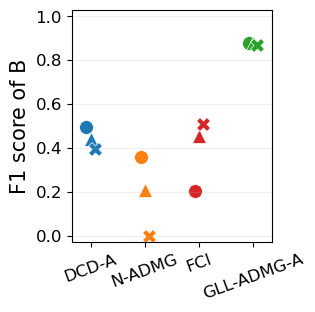

In [ ]:
x_labels = ["DCD-A", "N-ADMG", "FCI", "GLL-ADMG-A"] if g=="ancestral" else ["DCD-BF", "N-ADMG", "FCI", "GLL-ADMG-BF"]
method_pos = {'linear': 0, 'nonlinear': 1, 'fci': 2, 'base': 3}
marker_map = {'d4': 'o', 'd8': '^', 'd12': 'X'}
color_map = {
    'linear': 'tab:blue',
    'nonlinear': 'tab:orange',
    'fci': 'tab:red',
    'base': 'tab:green'
}

plt.figure(figsize=(3.0, 3.0))

for name, vals in methods.items():

    if "_nonlinear" in name:
        method = "nonlinear"
    elif "_linear" in name:
        method = "linear"
    elif "_fci" in name:
        method = "fci"
    else:
        method = "base"

    if "d4" in name:
        dim = "d4"
    elif "d8" in name:
        dim = "d8"
    elif "d12" in name:
        dim = "d12"
    else:
        continue

    x = method_pos[method] + offset_map[dim]
    y = vals["W2"]          

    plt.scatter(x, y, marker=marker_map[dim], color=color_map[method], s=100, edgecolors='white',   # outline

    linewidths=0.5)

for dim, marker in marker_map.items():
    label = f"d={dim[1:]}"
    plt.scatter([], [], marker=marker, color='black', label=label)

plt.xticks([0, 1, 2, 3], x_labels, rotation=20)
plt.ylim(-0.03, 1.03)
plt.xlim(-0.35, 3.35)
plt.ylabel("F1 score of B")

plt.grid(axis='y', alpha=0.2)

plt.tight_layout(pad=0.2)
plt.savefig(f"W2_{g}_{m}.pdf", bbox_inches='tight')
plt.show()

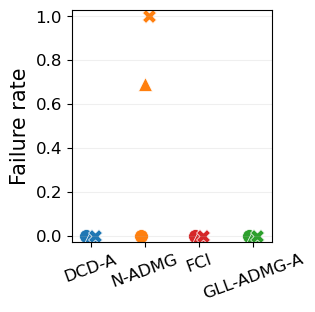

In [ ]:
x_labels = ["DCD-A", "N-ADMG", "FCI", "GLL-ADMG-A"] if g=="ancestral" else ["DCD-BF", "N-ADMG", "FCI", "GLL-ADMG-BF"]
for name, vals in methods.items():
    if "d12" in name and "_nonlinear" in name:
        vals["failure_rate"] = 1.0
        
method_pos = {'linear': 0, 'nonlinear': 1, 'fci': 2, 'base': 3}
marker_map = {'d4': 'o', 'd8': '^', 'd12': 'X'}
color_map = {
    'linear': 'tab:blue',
    'nonlinear': 'tab:orange',
    'fci': 'tab:red',
    'base': 'tab:green'
}

plt.figure(figsize=(3.0, 3.0))
for name, vals in methods.items():

    if "_nonlinear" in name:
        method = "nonlinear"
    elif "_linear" in name:
        method = "linear"
    elif "_fci" in name:
        method = "fci"
    else:
        method = "base"

    if "d4" in name:
        dim = "d4"
    elif "d8" in name:
        dim = "d8"
    elif "d12" in name:
        dim = "d12"
    else:
        continue

    if "failure_rate" not in vals:
        continue  # skip methods without failure_rate

    x = method_pos[method] + offset_map[dim]
    y = vals["failure_rate"]

    plt.scatter(x, y, marker=marker_map[dim], color=color_map[method], s=100, edgecolors='white', linewidths=0.5)

for dim, marker in marker_map.items():
    label = f"d={dim[1:]}"
    plt.scatter([], [], marker=marker, color='black', label=label)

plt.xticks([0, 1, 2, 3], x_labels, rotation=20)
plt.ylabel("Failure rate")
plt.ylim(-0.03, 1.03)
plt.xlim(-0.35, 3.35)

plt.grid(axis='y', alpha=0.2)

plt.grid(axis='y', alpha=0.2)

plt.tight_layout(pad=0.2)
plt.savefig(f"failure_{g}_{m}.pdf", bbox_inches='tight')
plt.show()


### realData

In [130]:
result_dic = {}
folder = {"realData", "realData_linear", "fci_realData"}  

for f in folder:
    W1_thres = 0.3
    W2_thres = 0.2
    TP_tot_W1 = 0
    FP_tot_W1 = 0
    FN_tot_W1 = 0

    TP_tot_W2 = 0
    FP_tot_W2 = 0
    FN_tot_W2 = 0

    run_time_count = 0
    run_time_tot = 0
    tot = 0

    for filename in os.listdir(f):

        file_path = os.path.join(f, filename)
        print("Processing:", file_path)

        with open(file_path, "r") as d:
            data = json.load(d)

        # --- truth ---
        admg = data["admg"]
        W_truth, Sigma_truth = admg_to_adjacency(admg)
        # W_truth = np.array(data["W_truth"])
        # Sigma_truth = np.array(data["Sigma_truth"])  # assumes this key exists

        # W_truth[np.abs(W_truth) < W1_thres] = 0
        # Sigma_truth[np.abs(Sigma_truth) < W2_thres] = 0

        # --- pick run_id == 0 ---
        W_est = None
        Sigma_est = None
        chosen_run = None

        if "nonlinear" in f:
            W_est = np.array(data["directed_adj_final"]) 
            Sigma_est = np.array(data["bidirected_adj_final"])
            run_time = data.get("train_running_time_mean")
            W_est[np.abs(W_est) < W1_thres] = 0
            Sigma_est[np.abs(Sigma_est) < W2_thres] = 0
            
        elif "linear" in f or "fci" in f:
            W_est = np.array(data["A_dir"])
            Sigma_est = np.array(data["A_bidir"])
            run_time = data["run_time_sec"]
       
        else:
            for run in data["random_runs"]:
                if run["run_id"] == 0:
                    chosen_run = run
                    W_est = np.array(run["W_est_random"])
                    Sigma_est = np.array(run["Sigma_est_random"])
                    run_time = run["run_time_sec"]
                    W_est[np.abs(W_est) < W1_thres] = 0
                    Sigma_est[np.abs(Sigma_est) < W2_thres] = 0
                    break

        if W_est is None or Sigma_est is None:
            print(f"  Skipping {filename}: run_id == 0 not found.")
            continue

        # --- F1 for W ---
        TP_W1, FP_W1, FN_W1, precision_W1, recall_W1, f1_W1 = f1_from_nonzero(W_truth, W_est)

        # --- F1 for Sigma (strictly lower-triangular) ---
        TP_W2, FP_W2, FN_W2, precision_W2, recall_W2, f1_W2 = f1_from_nonzero(
            np.tril(Sigma_truth, k=-1),
            np.tril(Sigma_est,   k=-1),
        )

        TP_tot_W1 += TP_W1
        FP_tot_W1 += FP_W1
        FN_tot_W1 += FN_W1

        TP_tot_W2 += TP_W2
        FP_tot_W2 += FP_W2
        FN_tot_W2 += FN_W2

        tot += 1
        if run_time is not None and np.isfinite(run_time):
            run_time_tot += float(run_time)
            run_time_count += 1
        else:
            print(f"  Warning: runtime missing in {filename}")

    precision_W1, recall_W1, f1_W1 = prf(TP_tot_W1, FP_tot_W1, FN_tot_W1)
    precision_W2, recall_W2, f1_W2 = prf(TP_tot_W2, FP_tot_W2, FN_tot_W2)

    run_time_avg = run_time_tot / run_time_count if run_time_count > 0 else 0

    result_dic[f"{f}_precision_W1"]=precision_W1
    result_dic[f"{f}_recall_W1"]=recall_W1
    result_dic[f"{f}_f1_W1"]=f1_W1

    result_dic[f"{f}_precision_W2"]=precision_W2
    result_dic[f"{f}_recall_W2"]=recall_W2
    result_dic[f"{f}_f1_W2"]=f1_W2
    result_dic[f"{f}_run_time"]=run_time_avg

Processing: realData_linear/realData_ancestral_linear.json
Processing: realData/realData_ancestral.json
Processing: fci_realData/realData_fci.json


In [ ]:
result_dic

{'fci_realData_precision_W1': np.float64(0.4),
 'fci_realData_recall_W1': np.float64(0.16666666666666666),
 'fci_realData_f1_W1': np.float64(0.23529411764705882),
 'fci_realData_precision_W2': np.float64(0.0),
 'fci_realData_recall_W2': np.float64(0.0),
 'fci_realData_f1_W2': 0.0,
 'fci_realData_run_time': 0.322873517870903,
 'realData_precision_W1': np.float64(1.0),
 'realData_recall_W1': np.float64(0.08333333333333333),
 'realData_f1_W1': np.float64(0.15384615384615385),
 'realData_precision_W2': np.float64(0.22857142857142856),
 'realData_recall_W2': np.float64(0.8),
 'realData_f1_W2': np.float64(0.3555555555555555),
 'realData_run_time': 10454.357028879225,
 'realData_linear_precision_W1': np.float64(0.19047619047619047),
 'realData_linear_recall_W1': np.float64(0.3333333333333333),
 'realData_linear_f1_W1': np.float64(0.24242424242424246),
 'realData_linear_precision_W2': 0.0,
 'realData_linear_recall_W2': np.float64(0.0),
 'realData_linear_f1_W2': 0.0,
 'realData_linear_run_time'

In [ ]:
names = list(methods.keys())
x = np.arange(len(names))
cmap = plt.get_cmap("tab10")
colors = {name: cmap(i) for i, name in enumerate(names)}

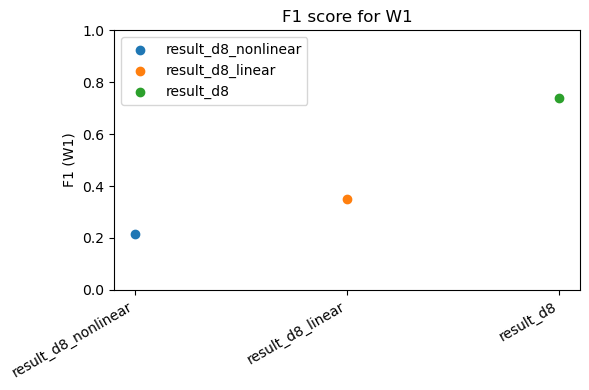

In [8]:
plt.figure(figsize=(6, 4))

for i, name in enumerate(names):
    if "W1" in methods[name]:
        plt.scatter(
            x[i],
            methods[name]["W1"],
            color=colors[name],
            label=name
        )

plt.xticks(x, names, rotation=30, ha="right")
plt.ylim(0, 1)
plt.ylabel("F1 (W1)")
plt.title("F1 score for W1")

plt.legend()
plt.tight_layout()
plt.show()



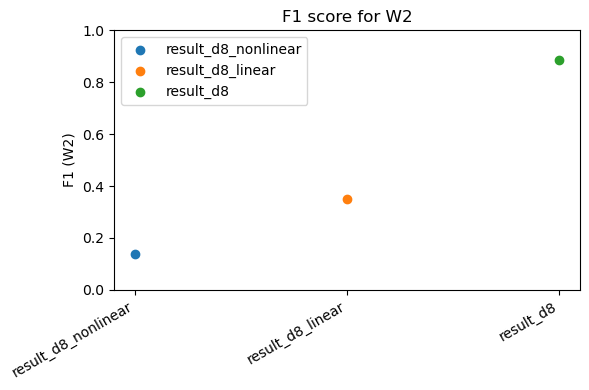

In [9]:
plt.figure(figsize=(6, 4))

for i, name in enumerate(names):
    if "W2" in methods[name]:
        plt.scatter(
            x[i],
            methods[name]["W2"],
            color=colors[name],
            label=name
        )

plt.xticks(x, names, rotation=30, ha="right")
plt.ylim(0, 1)
plt.ylabel("F1 (W2)")
plt.title("F1 score for W2")

plt.legend()
plt.tight_layout()
plt.show()

